In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

print("Libraries imported successfully")



Libraries imported successfully


In [35]:
df = pd.read_csv("Titanic_train.csv")

df.head()



,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [36]:
df.shape



(891, 12)

In [37]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [15]:
train_df.describe()


,PassengerId,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,3.000000,76.000000,8.000000,9.000000,512.329200


In [38]:
eda_df = pd.read_csv("Titanic_train.csv")
eda_df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


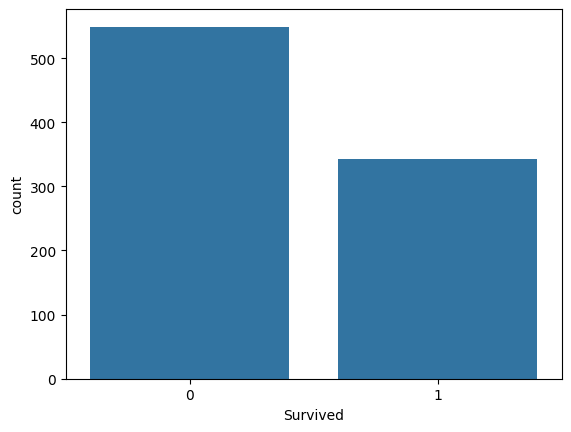

In [39]:
sns.countplot(x="Survived", data=eda_df)
plt.show()



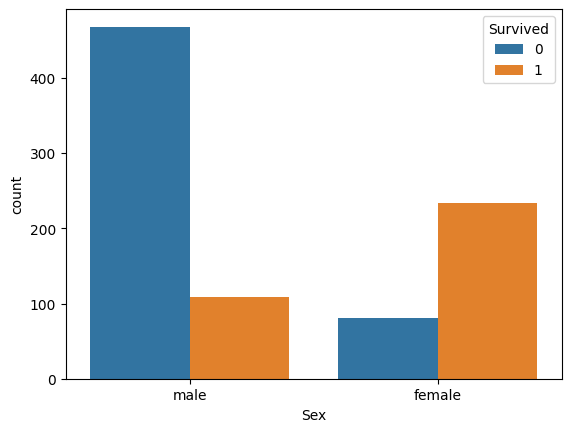

In [40]:
sns.countplot(x="Sex", hue="Survived", data=eda_df)
plt.show()


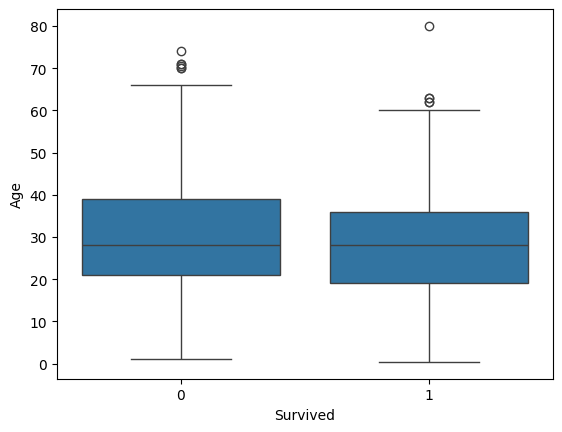

In [41]:
sns.boxplot(x="Survived", y="Age", data=eda_df)
plt.show()




In [42]:
y = df["Survived"]
X = df.drop("Survived", axis=1)

X.head(), y.head()



(   PassengerId  Pclass                                               Name  \
 0            1       3                            Braund, Mr. Owen Harris   
 1            2       1  Cumings, Mrs. John Bradley (Florence Briggs Th...   
 2            3       3                             Heikkinen, Miss. Laina   
 3            4       1       Futrelle, Mrs. Jacques Heath (Lily May Peel)   
 4            5       3                           Allen, Mr. William Henry   
 
       Sex   Age  SibSp  Parch            Ticket     Fare Cabin Embarked  
 0    male  22.0      1      0         A/5 21171   7.2500   NaN        S  
 1  female  38.0      1      0          PC 17599  71.2833   C85        C  
 2  female  26.0      0      0  STON/O2. 3101282   7.9250   NaN        S  
 3  female  35.0      1      0            113803  53.1000  C123        S  
 4    male  35.0      0      0            373450   8.0500   NaN        S  ,
 0    0
 1    1
 2    1
 3    1
 4    0
 Name: Survived, dtype: int64)

In [43]:
X = X.drop(["PassengerId", "Name", "Ticket", "Cabin"], axis=1)

X.head()



,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,22.0,1,0,7.2500,S
1,1,female,38.0,1,0,71.2833,C
2,3,female,26.0,0,0,7.9250,S
3,1,female,35.0,1,0,53.1000,S
4,3,male,35.0,0,0,8.0500,S


In [44]:
X["Age"].fillna(X["Age"].median(), inplace=True)
X["Embarked"].fillna(X["Embarked"].mode()[0], inplace=True)

print("Missing values handled")



Missing values handled


/tmp/ipython-input-2753098121.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X["Age"].fillna(X["Age"].median(), inplace=True)
/tmp/ipython-input-2753098121.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

In [45]:
X = pd.get_dummies(X, drop_first=True)

X.head()



,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,3,22.0,1,0,7.2500,True,False,True
1,1,38.0,1,0,71.2833,False,False,False
2,3,26.0,0,0,7.9250,False,False,True
3,1,35.0,1,0,53.1000,False,False,True
4,3,35.0,0,0,8.0500,True,False,True


In [46]:
X.dtypes



,0
Pclass,int64
Age,float64
SibSp,int64
Parch,int64
Fare,float64
Sex_male,bool
Embarked_Q,bool
Embarked_S,bool


In [47]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape





((712, 8), (179, 8))

In [48]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

print("Logistic Regression model trained successfully")


Logistic Regression model trained successfully


In [49]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))


Accuracy: 0.8100558659217877
Precision: 0.7857142857142857
Recall: 0.7432432432432432
F1 Score: 0.7638888888888888
ROC-AUC: 0.8826254826254826


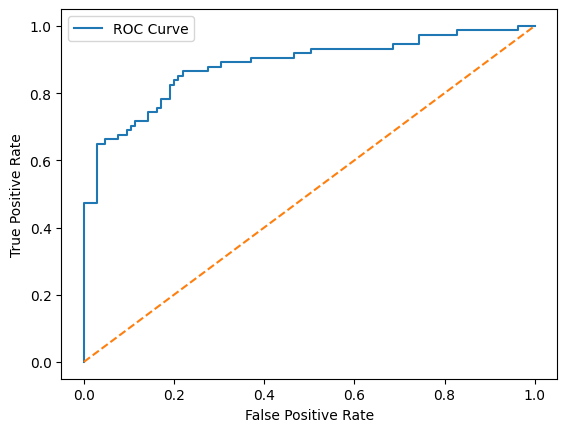

In [50]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr, label="ROC Curve")
plt.plot([0,1], [0,1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()


In [51]:
coeff_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

coeff_df.sort_values(by="Coefficient", ascending=False).head()


,Feature,Coefficient
4,Fare,0.002591
1,Age,-0.030537
3,Parch,-0.108108
6,Embarked_Q,-0.113105
2,SibSp,-0.295244


In [54]:
# Load test dataset
test_df = pd.read_csv("Titanic_test.csv")

# Drop text columns
test_df.drop(["PassengerId", "Name", "Ticket", "Cabin"], axis=1, inplace=True)

# Handle missing values
test_df["Age"].fillna(test_df["Age"].median(), inplace=True)
test_df["Embarked"].fillna(test_df["Embarked"].mode()[0], inplace=True)

# Encode categorical variables
test_df = pd.get_dummies(test_df, drop_first=True)

# Align columns with training data
test_df = test_df.reindex(columns=X.columns, fill_value=0)

# VERY IMPORTANT FIX
test_df.fillna(0, inplace=True)

# Predict survival
test_predictions = model.predict(test_df)

test_predictions[:10]



/tmp/ipython-input-1604372876.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test_df["Age"].fillna(test_df["Age"].median(), inplace=True)
/tmp/ipython-input-1604372876.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tr

array([0, 0, 0, 0, 1, 0, 1, 0, 1, 0])